In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from glob import glob

In [ ]:
# def draw_contours(image, contours, labels=None):
#     boxed = image.copy()
#     for i, cnt in enumerate(contours):
#         x, y, w, h = cv2.boundingRect(cnt)
#         cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 3)
#         if labels and i < len(labels):
#             cv2.putText(boxed, labels[i], (x, y + 40), cv2.FONT_HERSHEY_SIMPLEX,
#                         2.0, (0, 0, 255), 4, lineType=cv2.LINE_AA)
#     return boxed

# # --------- Step 1: K-means Color Clustering ---------
# def kmeans_clustering(image, k=4):
#     Z = image.reshape((-1, 3))
#     Z = np.float32(Z)
#     kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
#     labels = kmeans.labels_.reshape(image.shape[:2])
#     clustered_img = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
#     return clustered_img, labels

# def extract_class_masks(labels, num_classes=4):
#     masks = []
#     for i in range(num_classes):
#         mask = np.uint8(labels == i) * 255
#         masks.append(mask)
#     return masks

# # def clean_mask(mask):
# #     # Larger kernels to suppress small dots and merge nearby blobs
# #     kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
# #     kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

# #     opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
# #     closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    
# #     # Optional: strengthen structure further
# #     dilated = cv2.dilate(closed, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
# #     return dilated

# def remove_small_components(mask, min_size=15000):
#     nb_components, output, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
#     cleaned_mask = np.zeros(mask.shape, dtype=np.uint8)

#     for i in range(1, nb_components):  # Skip background (label 0)
#         if stats[i, cv2.CC_STAT_AREA] >= min_size:
#             cleaned_mask[output == i] = 255

#     return cleaned_mask

# def clean_mask(mask, morph_size=60, min_component_size=15000):
    
#     mask = cv2.medianBlur(mask, 5)
#     # Morphological kernel
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_size, morph_size))
    
#     # Step 1: Remove noise (small white blobs)
#     opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
#     # Step 2: Fill gaps in the mask
#     closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    
#     # Step 3: Remove small connected components
#     cleaned = remove_small_components(closed, min_size=min_component_size)
    
#     return cleaned

# def apply_morphology(binary_img):
#     # Use a small kernel to preserve detail while smoothing
#     kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
#     kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

#     # Opening removes small noise
#     opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel_open, iterations=2)

#     # Closing fills small holes
#     closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close, iterations=1)

#     return closed

# def remove_shadows(gray_img):
#     dilated_img = cv2.dilate(gray_img, np.ones((15,15), np.uint8))
#     bg_img = cv2.medianBlur(dilated_img, 31)
#     # Convert to float to prevent clipping during division
#     gray_float = gray_img.astype(np.float32)
#     background_float = bg_img.astype(np.float32) + 1  # prevent division by zero

#     # Normalize shadowed areas (dividing by background intensity)
#     normalized = (gray_float / background_float) * 128  # scale to mid-level
#     normalized = np.clip(normalized, 0, 255).astype(np.uint8)
#     return normalized

# def get_contours_from_mask(mask, min_area=1500, size_range=(450, 700)): #Change here 450 to 700
#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     filtered = []
#     for c in contours:
#         x, y, w, h = cv2.boundingRect(c)
#         if (min_area < cv2.contourArea(c) and
#             size_range[0] <= w <= size_range[1] and
#             size_range[0] <= h <= size_range[1]):
#             filtered.append(c)
#     return filtered


# # --------- Step 3: Histogram Extraction ---------
# def extract_histogram(img, contour):
#     x, y, w, h = cv2.boundingRect(contour)
#     roi = img[y:y+h, x:x+w]
#     hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
#     cv2.normalize(hist, hist)
#     return hist.flatten()

# # def match_histogram(hist, reference_histograms):
# #     return max(reference_histograms.items(),
# #                key=lambda item: cv2.compareHist(hist, item[1], cv2.HISTCMP_CORREL))[0]


# # --------- Step 4: Reference Histogram Creation ---------
# def load_reference_histograms(ref_folder):
#     histograms = {}
#     for path in glob(os.path.join(ref_folder, '*.jpg')):
#         img = cv2.imread(path)
#         clustered_img, labels = kmeans_clustering(img, k=4)
#         masks = extract_class_masks(labels)
#         for i, mask in enumerate(masks):
#             cleaned = clean_mask(mask)
#             contours = get_contours_from_mask(cleaned)
#             if contours:
#                 hist = extract_histogram(img, contours[0])
#                 filename = os.path.basename(path)
#                 class_name = filename.split('_JPG')[0]
#                 histograms[class_name] = hist
#                 break
#     return histograms


# # --------- Step 5: Histogram Comparison ---------
# def match_histogram(hist, reference_histograms):
#     scores = {cls: cv2.compareHist(hist, ref, cv2.HISTCMP_CORREL) for cls, ref in reference_histograms.items()}
#     return max(scores, key=scores.get)

# # --------- Step 6: Run Full Pipeline on Image ---------
# # def process_image_kmeans_only(img_path, reference_histograms):
# #     img = cv2.imread(img_path)
# #     clustered_img, labels = kmeans_clustering(img, k=4)
# #     class_masks = extract_class_masks(labels)

# #     all_contours = []
# #     all_labels = []

# #     for mask in class_masks:
# #         cleaned = clean_mask(mask)
# #         contours = get_contours_from_mask(cleaned)
# #         for cnt in contours:
# #             hist = extract_histogram(img, cnt)
# #             best_label = match_histogram(hist, reference_histograms)
# #             all_contours.append(cnt)
# #             all_labels.append(best_label)

# #     display_results(img, clustered_img, all_contours, all_labels)

# def process_image_kmeans_only(img, reference_histograms):
#     clustered_img, labels = kmeans_clustering(img, k=4)
#     class_masks = extract_class_masks(labels)

#     all_contours = []
#     all_labels = []

#     for mask in class_masks:
#         cleaned = clean_mask(mask)
#         contours = get_contours_from_mask(cleaned)
#         for cnt in contours:
#             hist = extract_histogram(img, cnt)
#             best_label = match_histogram(hist, reference_histograms)
#             all_contours.append(cnt)
#             all_labels.append(best_label)

#     display_results(img, clustered_img, all_contours, all_labels)

# # --------- Visualization ---------
# def display_results(orig, clustered, contours, labels):
#     clustered_boxes = draw_contours(clustered, contours)
#     original_boxes = draw_contours(orig.copy(), contours)
#     labeled_img = draw_contours(orig.copy(), contours, labels)

#     fig, axs = plt.subplots(1, 3, figsize=(20, 8))  # Slightly larger figure
#     axs[0].imshow(cv2.cvtColor(clustered_boxes, cv2.COLOR_BGR2RGB))
#     axs[0].set_title('K-means with BBoxes', fontsize=24)
#     axs[1].imshow(cv2.cvtColor(original_boxes, cv2.COLOR_BGR2RGB))
#     axs[1].set_title('Original with BBoxes', fontsize=24)
#     axs[2].imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
#     axs[2].set_title('Final Classification', fontsize=24)

#     for ax in axs:
#         ax.axis('off')

#     plt.tight_layout()
#     plt.show()



In [ ]:
ref_histograms = load_reference_histograms(r'images\references')
test_folder = r'images\robo\valid'
for img_path in glob(os.path.join(test_folder, "*.jpg")):
    process_image_kmeans_only(img_path, ref_histograms)

Compare pixels to Colorhistograms made from reference images

In [ ]:
def visualize_color_histogram(hist, title='Color Histogram'):
    hist_reshaped = hist.reshape((8, 8, 8))
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    bin_edges = np.linspace(0, 255, 9)[:-1]  # Center points of bins
    for r in range(8):
        for g in range(8):
            for b in range(8):
                val = hist_reshaped[r, g, b]
                if val > 0.01:  # Skip negligible bins
                    ax.scatter(bin_edges[r], bin_edges[g], bin_edges[b],
                               c=np.array([[bin_edges[r], bin_edges[g], bin_edges[b]]]) / 255,
                               s=val * 5000)

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(title)
    plt.show()


In [ ]:
reference_histograms = load_reference_histograms(r'images\references')
for name, hist in reference_histograms.items():
    visualize_color_histogram(hist, title=f"Histogram for {name}")

In [ ]:
def filter_image_by_histograms(image, reference_histograms, threshold=0.75, visualize=True):
    """
    Iterate through image pixels, keep only those likely to belong to any chocolate class.
    The pixel is kept if a patch around it matches any reference histogram reasonably well.
    """
    h, w, _ = image.shape
    result = np.ones_like(image) * 255  # Start with white image
    mask_visual = np.zeros((h, w), dtype=np.uint8)  # For visualization of kept pixels
    patch_size = 20  # small patch around each pixel for local histogram
    
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            y_end = min(y + patch_size, h)
            x_end = min(x + patch_size, w)
            patch = image[y:y_end, x:x_end]

            hist = cv2.calcHist([patch], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
            cv2.normalize(hist, hist)
            flat_hist = hist.flatten()

            best_score = max(
                cv2.compareHist(flat_hist, ref_hist, cv2.HISTCMP_CORREL)
                for ref_hist in reference_histograms.values()
            )

            if best_score >= threshold:
                result[y:y_end, x:x_end] = image[y:y_end, x:x_end]  # Keep original pixels
                mask_visual[y:y_end, x:x_end] = 255
                
    # Post-process mask to clean it
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mask_cleaned = cv2.morphologyEx(mask_visual, cv2.MORPH_CLOSE, kernel)
    mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)
    
    result[mask_cleaned == 0] = 255  # Set all background pixels to white
                
    if visualize:
        fig, axs = plt.subplots(1, 4, figsize=(20, 6))
        axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Original Image")
        axs[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        axs[1].set_title("Filtered Image (Histogram Match)")
        axs[2].imshow(mask_visual, cmap='gray')
        axs[2].set_title("Pixel Mask (Kept Pixels)")
        axs[3].imshow(mask_cleaned, cmap='gray')
        axs[3].set_title("Pixel Mask cleaned (Kept Pixels)")

        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return result, mask_cleaned

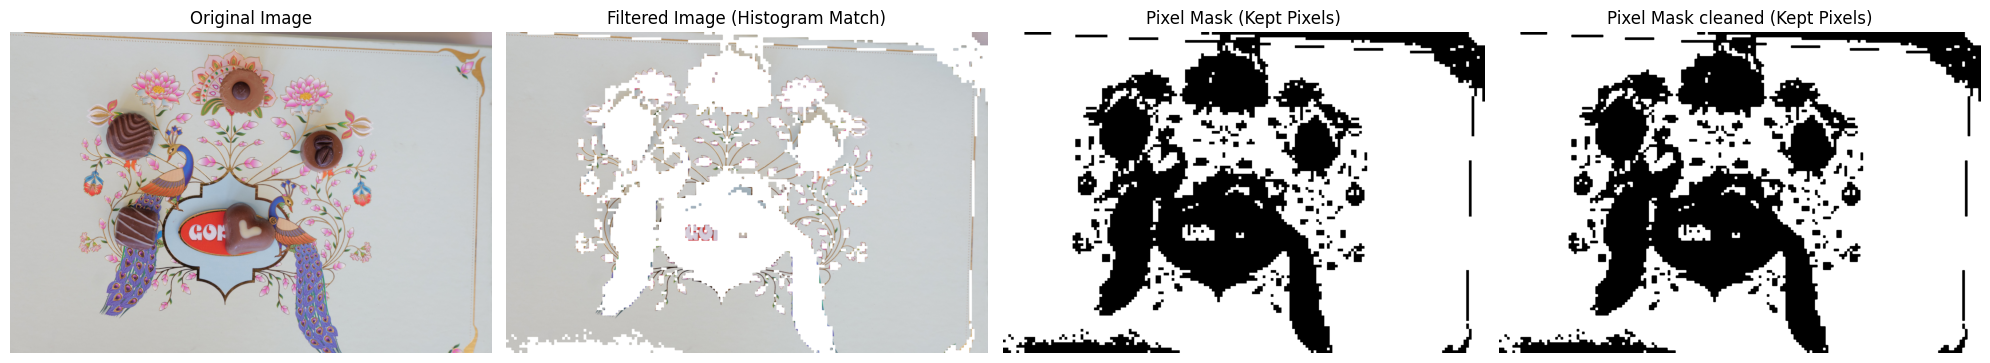

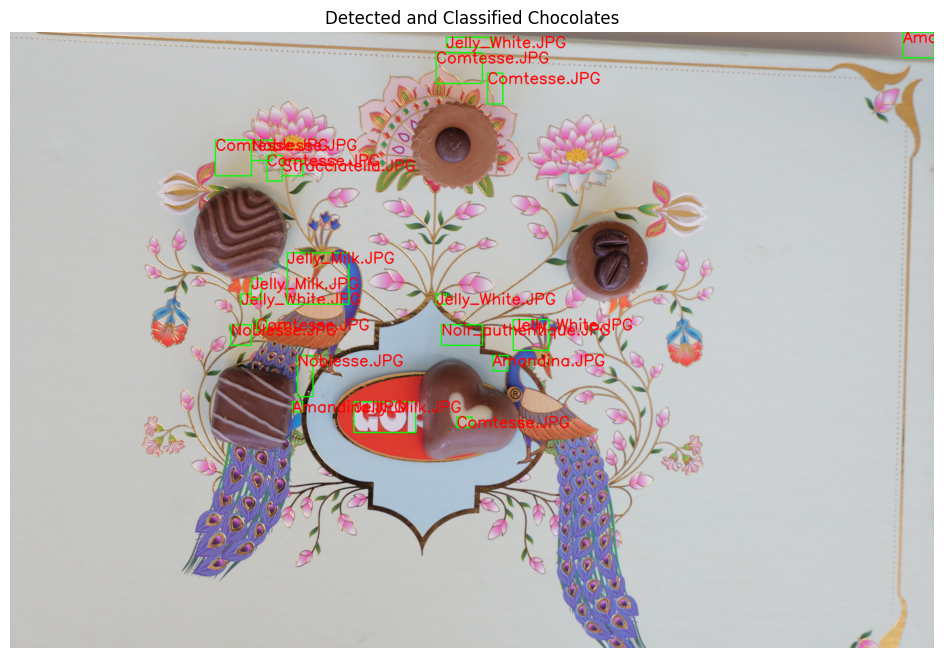

In [67]:
image_path = r'images\robo\valid\L1000900_JPG.rf.2959d78d15c75224722cc3a256313c58.jpg'
image = cv2.imread(image_path)
scale = 0.6
resized_image = cv2.resize(image, (0, 0), fx=scale, fy=scale)
# smoothed_image = cv2.medianBlur(resized_image, 5)
cleaned_img, mask_cleaned = filter_image_by_histograms(resized_image, reference_histograms)
contours, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if 1000 < area < 100000:  # You may adjust these bounds
        filtered_contours.append(cnt)
contours = filtered_contours

# Step 3: Classify each contour
labels = []
for cnt in contours:
    hist = extract_histogram(resized_image, cnt)
    label = match_histogram(hist, reference_histograms)
    labels.append(label)

# Step 4: Draw results
result_img = draw_contours(resized_image, contours, labels)

# Step 5: Visualize
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title("Detected and Classified Chocolates")
plt.axis('off')
plt.show()
# process_image_kmeans_only(cleaned_img, reference_histograms)

First do kmeans and then region histogram filtering